# Task 2.1.1: Introduction to Object Detection
## Definition and purpose of object detection in computer vision

In [3]:
# Importing required libraries, which include:
# OpenCV library used for the many tasks in computer vision, from loading images, to processing, detecting, shapes, tracking objects etc.:
import cv2
# Numpy is very useful computation library, here we can use it to compute means:
import numpy as np
# We need the following to show images as plots (x and y axes), later we will use it to draw actual plots too:
import matplotlib.pyplot as plt
# We need the following to draw areas of interest on our plots and images:
import matplotlib.patches as patches

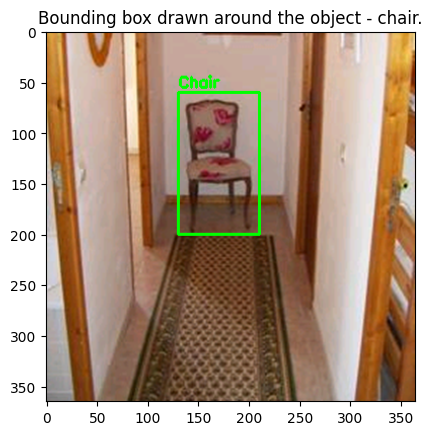

In [6]:
# See how bounding boxes are drawn around the detected objects

# Load the input image
image = cv2.imread("data/chair.png")

# Switching channels from BGR to RGB
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Define the pre-defined object detection results (bounding boxes and class labels)
detections = [
    {
        "class_label": "Chair",
        "bounding_box": (130, 60, 210, 200)  # (x1, y1, x2, y2)
    },
]

# Loop over the detections and draw bounding boxes
for detection in detections:
    class_label = detection["class_label"]
    x1, y1, x2, y2 = detection["bounding_box"]

    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Add optional text
    cv2.putText(img_rgb, class_label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Display the output image
plt.imshow(img_rgb)
plt.title("Bounding box drawn around the object - chair.")
plt.show()

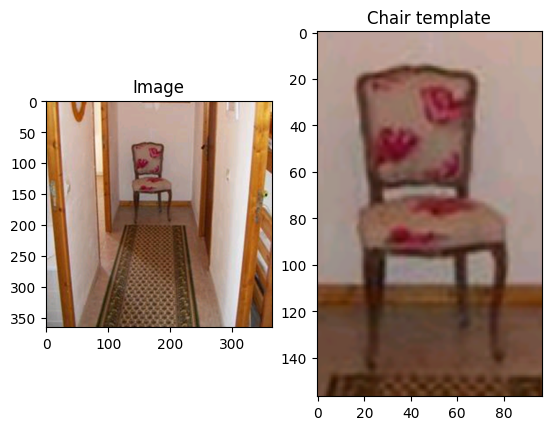

In [8]:
# Load up chair image and template image

# Load the images
mask = cv2.imread("data/chairmask.png")
image = cv2.imread("data/chair.png")

# Switching channels from BGR to RGB
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2)

# Display the first image on the left subplot
axs[0].imshow(image)
axs[0].set_title("Image")

# Display the second image on the right subplot
axs[1].imshow(mask)
axs[1].set_title("Chair template")

# Show the figure
plt.show()

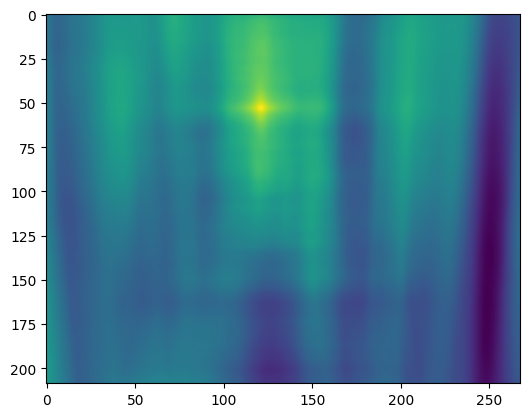

In [12]:
# Using the provided image and mask, perform correlation to find the location of the chair in the image.

result = cv2.matchTemplate(image, mask, cv2.TM_CCORR_NORMED)

# Display the result
plt.imshow(result)

# Get the current reference
ax = plt.gca()

plt.show()


room: (325, 439, 3) mask: (165, 219, 3)


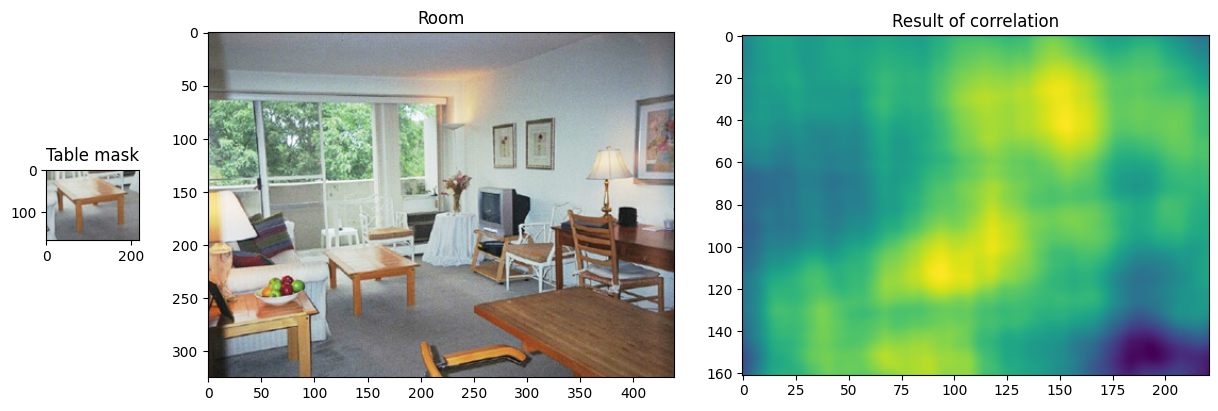

In [10]:
# TASK: Template matching and normalized correlation
# TODO Change chair mask to find different objects in the room

# Load the image
room = cv2.imread("data/room.png")
mask = cv2.imread("data/table.png")

# Switching channels from BGR to RGB
room = cv2.cvtColor(room, cv2.COLOR_BGR2RGB)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

mask = cv2.resize(mask, None, fx=0.8, fy=0.8, interpolation=cv2.INTER_AREA)
print("room:", room.shape, "mask:", mask.shape)

# Perform normalized correlation using cv2.matchTemplate
result2 = cv2.matchTemplate(room, mask, cv2.TM_CCORR_NORMED)

# Create a figure with two subplots
fig, axs = plt.subplots(1, 3, gridspec_kw={'width_ratios': [1, 5, 5]}, figsize=(15,15))

# Displaying the images on the subplots
axs[0].imshow(mask)
axs[0].set_title("Table mask")

axs[1].imshow(room)
axs[1].set_title("Room")

axs[2].imshow(result2)
axs[2].set_title("Result of correlation")

# Show the figure
plt.show()